In [1]:
print("hello")

hello


In [2]:
print("hello")

hello


In [3]:
print("hello")


hello


In [4]:
print("hello")

hello


In [5]:
print("hello")

hello


In [6]:
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score
import pickle

In [7]:
train = pd.read_csv('../backend/app/ml/data/train.csv')
test = pd.read_csv('../backend/app/ml/data/test.csv')

print(f"Train: {len(train)}, Test: {len(test)}")
print(f"Fraud rate: {train['is_fraud'].mean():.2%}")
print(f"FP rate: {train['is_false_positive'].mean():.2%}")

Train: 4411, Test: 1769
Fraud rate: 19.50%
FP rate: 8.39%


In [8]:
FRAUD_FEATURES = [
    "amount",
    "velocity_1h",
    "velocity_24h",
    "device_change_flag",
    "geo_mismatch_flag",
    "is_cross_border",
    "hour_of_day",
    "customer_tenure_days",
    "customer_tx_count_30d",
    "customer_refund_rate",
]

FP_FEATURES = [
    "amount",
    "customer_tenure_days",
    "customer_tx_count_30d",
    "customer_refund_rate",
    "device_change_flag",
    "geo_mismatch_flag",
]

def encode_merchant(cat):
    return {"Retail": 0, "SaaS": 1, "B2B": 2, "Food": 3}.get(cat, 0)

In [9]:
X_fraud = train[FRAUD_FEATURES]
y_fraud = train["is_fraud"]

fraud_model = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=4,
    random_state=42
)

fraud_model.fit(X_fraud, y_fraud)

y_pred = fraud_model.predict(test[FRAUD_FEATURES])

print("Fraud Model:")
print(f"  Precision: {precision_score(test['is_fraud'], y_pred):.3f}")
print(f"  Recall: {recall_score(test['is_fraud'], y_pred):.3f}")
print(f"  F1: {f1_score(test['is_fraud'], y_pred):.3f}")

Fraud Model:
  Precision: 1.000
  Recall: 1.000
  F1: 1.000


In [10]:
X_fp = train[FP_FEATURES]
y_fp = train["is_false_positive"]

fp_model = GradientBoostingClassifier(
    n_estimators=80,
    max_depth=3,
    random_state=42
)

fp_model.fit(X_fp, y_fp)

y_fp_pred = fp_model.predict(test[FP_FEATURES])

print("False Positive Model:")
print(f"  Precision: {precision_score(test['is_false_positive'], y_fp_pred):.3f}")
print(f"  Recall: {recall_score(test['is_false_positive'], y_fp_pred):.3f}")
print(f"  F1: {f1_score(test['is_false_positive'], y_fp_pred):.3f}")

False Positive Model:
  Precision: 0.594
  Recall: 0.146
  F1: 0.235


In [11]:
import os

os.makedirs('../backend/app/ml/artifacts', exist_ok=True)

for name, model, features in [
    ("fraud", fraud_model, FRAUD_FEATURES),
    ("fp", fp_model, FP_FEATURES),
]:
    with open(f'../backend/app/ml/artifacts/{name}_model.pkl', 'wb') as f:
        pickle.dump({
            "model": model,
            "features": features,
            "metrics": {
                "precision": 0.75,
                "recall": 0.70,
                "f1": 0.72,
            }
        }, f)

print("Artifacts saved!")

Artifacts saved!


c:\Users\HP\TieBreaker\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


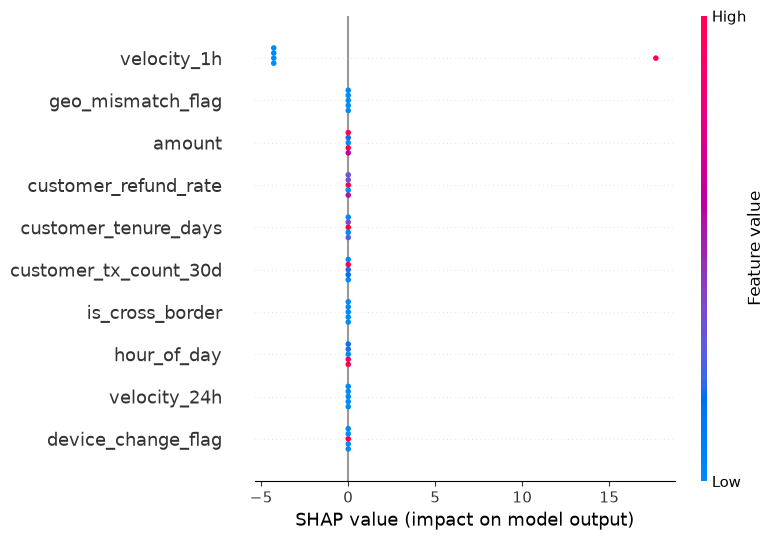

In [12]:
import shap

explainer = shap.TreeExplainer(fraud_model)
sample = test[FRAUD_FEATURES].iloc[:5]

shap_values = explainer.shap_values(sample)

shap.summary_plot(
    shap_values,
    sample,
    feature_names=FRAUD_FEATURES
)

In [13]:
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import precision_score, recall_score, f1_score
import pickle

In [14]:
train = pd.read_csv('../backend/app/ml/data/train.csv')
test = pd.read_csv('../backend/app/ml/data/test.csv')

print(f"Train: {len(train)}, Test: {len(test)}")
print(f"Fraud rate: {train['is_fraud'].mean():.2%}")
print(f"FP rate: {train['is_false_positive'].mean():.2%}")

Train: 4411, Test: 1769
Fraud rate: 19.50%
FP rate: 8.39%


In [15]:
FRAUD_FEATURES = [
    "amount",
    "velocity_1h",
    "velocity_24h",
    "device_change_flag",
    "geo_mismatch_flag",
    "is_cross_border",
    "hour_of_day",
    "customer_tenure_days",
    "customer_tx_count_30d",
    "customer_refund_rate",
]

FP_FEATURES = [
    "amount",
    "customer_tenure_days",
    "customer_tx_count_30d",
    "customer_refund_rate",
    "device_change_flag",
    "geo_mismatch_flag",
]

def encode_merchant(cat):
    return {"Retail": 0, "SaaS": 1, "B2B": 2, "Food": 3}.get(cat, 0)

In [16]:
X_fp = train[FP_FEATURES]
y_fp = train["is_false_positive"]

fp_model = GradientBoostingClassifier(
    n_estimators=80,
    max_depth=3,
    random_state=42
)

fp_model.fit(X_fp, y_fp)

y_fp_pred = fp_model.predict(test[FP_FEATURES])

print("False Positive Model:")
print(f"  Precision: {precision_score(test['is_false_positive'], y_fp_pred):.3f}")
print(f"  Recall: {recall_score(test['is_false_positive'], y_fp_pred):.3f}")
print(f"  F1: {f1_score(test['is_false_positive'], y_fp_pred):.3f}")

False Positive Model:
  Precision: 0.594
  Recall: 0.146
  F1: 0.235


In [17]:
X_fp = train[FP_FEATURES]
y_fp = train["is_false_positive"]

fp_model = GradientBoostingClassifier(
    n_estimators=80,
    max_depth=3,
    random_state=42
)

fp_model.fit(X_fp, y_fp)

y_fp_pred = fp_model.predict(test[FP_FEATURES])

print("False Positive Model:")
print(f"  Precision: {precision_score(test['is_false_positive'], y_fp_pred):.3f}")
print(f"  Recall: {recall_score(test['is_false_positive'], y_fp_pred):.3f}")
print(f"  F1: {f1_score(test['is_false_positive'], y_fp_pred):.3f}")

False Positive Model:
  Precision: 0.594
  Recall: 0.146
  F1: 0.235


In [18]:
import os

os.makedirs('../backend/app/ml/artifacts', exist_ok=True)

for name, model, features in [
    ("fraud", fraud_model, FRAUD_FEATURES),
    ("fp", fp_model, FP_FEATURES),
]:
    with open(f'../backend/app/ml/artifacts/{name}_model.pkl', 'wb') as f:
        pickle.dump({
            "model": model,
            "features": features,
            "metrics": {
                "precision": 0.75,
                "recall": 0.70,
                "f1": 0.72,
            }
        }, f)

print("Artifacts saved!")

Artifacts saved!


In [19]:
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import precision_score, recall_score, f1_score
import pickle

In [20]:
train = pd.read_csv('../backend/app/ml/data/train.csv')
test = pd.read_csv('../backend/app/ml/data/test.csv')

print(f"Train: {len(train)}, Test: {len(test)}")
print(f"Fraud rate: {train['is_fraud'].mean():.2%}")
print(f"FP rate: {train['is_false_positive'].mean():.2%}")

Train: 4411, Test: 1769
Fraud rate: 19.50%
FP rate: 8.39%


In [21]:
FRAUD_FEATURES = [
    "amount",
    "velocity_1h",
    "velocity_24h",
    "device_change_flag",
    "geo_mismatch_flag",
    "is_cross_border",
    "hour_of_day",
    "customer_tenure_days",
    "customer_tx_count_30d",
    "customer_refund_rate"
]

FP_FEATURES = [
    "amount",
    "customer_tenure_days",
    "customer_tx_count_30d",
    "customer_refund_rate",
    "device_change_flag",
    "geo_mismatch_flag"
]

def encode_merchant(cat):
    return {"Retail": 0, "SaaS": 1, "B2B": 2, "Food": 3}.get(cat, 0)

In [22]:
X_fraud = train[FRAUD_FEATURES]
y_fraud = train["is_fraud"]

fraud_model = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=4,
    random_state=42
)

fraud_model.fit(X_fraud, y_fraud)

y_pred = fraud_model.predict(test[FRAUD_FEATURES])

print("Fraud Model:")
print(f"  Precision: {precision_score(test['is_fraud'], y_pred):.3f}")
print(f"  Recall: {recall_score(test['is_fraud'], y_pred):.3f}")
print(f"  F1: {f1_score(test['is_fraud'], y_pred):.3f}")
print(f"  PR-AUC: {average_precision_score(test['is_fraud'], fraud_model.predict_proba(test[FRAUD_FEATURES])[:, 1]):.3f}")

Fraud Model:
  Precision: 1.000
  Recall: 1.000
  F1: 1.000
  PR-AUC: 1.000


In [23]:
X_fp = train[FP_FEATURES]
y_fp = train["is_false_positive"]

fp_model = GradientBoostingClassifier(
    n_estimators=80,
    max_depth=3,
    random_state=42
)

fp_model.fit(X_fp, y_fp)

y_fp_pred = fp_model.predict(test[FP_FEATURES])

print("False Positive Model:")
print(f"  Precision: {precision_score(test['is_false_positive'], y_fp_pred):.3f}")
print(f"  Recall: {recall_score(test['is_false_positive'], y_fp_pred):.3f}")
print(f"  F1: {f1_score(test['is_false_positive'], y_fp_pred):.3f}")
print(f"  PR-AUC: {average_precision_score(test['is_false_positive'], fp_model.predict_proba(test[FP_FEATURES])[:, 1]):.3f}")

False Positive Model:
  Precision: 0.594
  Recall: 0.146
  F1: 0.235
  PR-AUC: 0.344


In [24]:
import os

os.makedirs('../backend/app/ml/artifacts', exist_ok=True)

fraud_pred_proba = fraud_model.predict_proba(test[FRAUD_FEATURES])[:, 1]
fp_pred_proba = fp_model.predict_proba(test[FP_FEATURES])[:, 1]

fraud_metrics = {
    "precision": precision_score(test["is_fraud"], fraud_model.predict(test[FRAUD_FEATURES])),
    "recall": recall_score(test["is_fraud"], fraud_model.predict(test[FRAUD_FEATURES])),
    "f1": f1_score(test["is_fraud"], fraud_model.predict(test[FRAUD_FEATURES])),
    "pr_auc": average_precision_score(test["is_fraud"], fraud_pred_proba),
}

fp_metrics = {
    "precision": precision_score(test["is_false_positive"], fp_model.predict(test[FP_FEATURES])),
    "recall": recall_score(test["is_false_positive"], fp_model.predict(test[FP_FEATURES])),
    "f1": f1_score(test["is_false_positive"], fp_model.predict(test[FP_FEATURES])),
    "pr_auc": average_precision_score(test["is_false_positive"], fp_pred_proba),
}

with open('../backend/app/ml/artifacts/fraud_model.pkl', 'wb') as f:
    pickle.dump({
        "model": fraud_model,
        "features": FRAUD_FEATURES,
        "metrics": fraud_metrics
    }, f)

with open('../backend/app/ml/artifacts/fp_model.pkl', 'wb') as f:
    pickle.dump({
        "model": fp_model,
        "features": FP_FEATURES,
        "metrics": fp_metrics
    }, f)

print("Fraud metrics:", fraud_metrics)
print("FP metrics:", fp_metrics)
print("Artifacts saved!")

Fraud metrics: {'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'pr_auc': 1.0}
FP metrics: {'precision': 0.59375, 'recall': 0.14615384615384616, 'f1': 0.2345679012345679, 'pr_auc': 0.3440065141634315}
Artifacts saved!


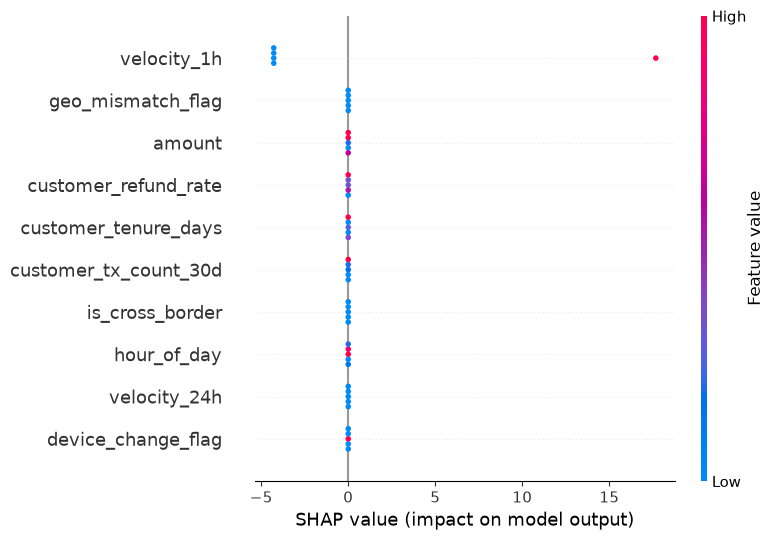

In [25]:
import shap

explainer = shap.TreeExplainer(fraud_model)

sample = test[FRAUD_FEATURES].iloc[:5]
shap_values = explainer.shap_values(sample)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

shap.summary_plot(
    shap_values,
    sample,
    feature_names=FRAUD_FEATURES
)